<a href="https://colab.research.google.com/github/Heng1222/Ohsumed_classification/blob/main/classification_data/abstract_token_length.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

正在載入資料集...
正在計算所有文本的 Token 長度...


  0%|          | 0/56984 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (515 > 512). Running this sequence through the model will result in indexing errors



--- 資料分析報告 ---
總樣本數: 56984
最大長度: 856
平均長度: 250.24
超過 512 tokens 的樣本數: 1387 (佔 2.43%)


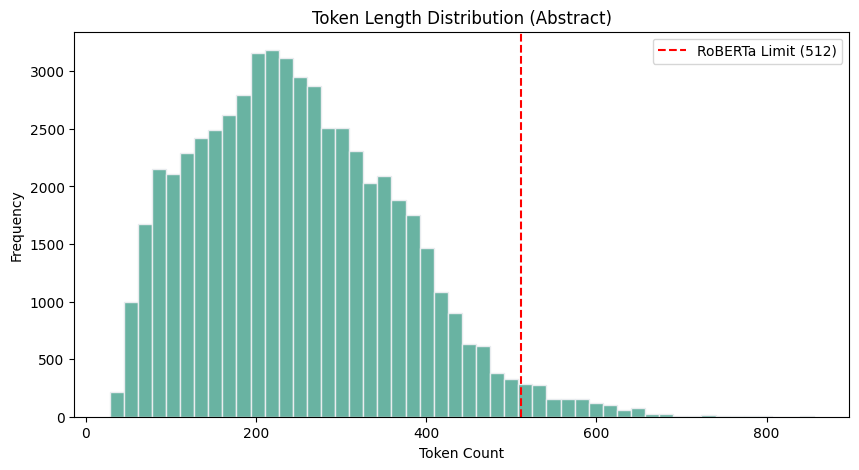

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import RobertaTokenizer
from tqdm.auto import tqdm

# 1. 載入資料
DATA_URL = "https://media.githubusercontent.com/media/Heng1222/Ohsumed_classification/refs/heads/main/classification_data/ohsumed_dataset.csv"
print("正在載入資料集...")
df = pd.read_csv(DATA_URL)

# 2. 預處理：合併標題與摘要
# 處理缺失值並使用 RoBERTa 的分隔符號 </s>
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
df['title'] = df['title'].fillna("")
df['abstract'] = df['abstract'].fillna("")
df['full_text'] = df['title'] + " " + tokenizer.sep_token + " " + df['abstract']

# 3. 分析 Token 長度
print("正在計算所有文本的 Token 長度...")
token_counts = []
for text in tqdm(df['abstract'].values):
    # encode 不進行 padding，只為了算長度
    tokens = tokenizer.encode(text, add_special_tokens=True)
    token_counts.append(len(tokens))

# 4. 顯示統計結果與圖表
max_len = max(token_counts)
over_512 = sum(1 for x in token_counts if x > 512)

print(f"\n--- 資料分析報告 ---")
print(f"總樣本數: {len(df)}")
print(f"最大長度: {max_len}")
print(f"平均長度: {np.mean(token_counts):.2f}")
print(f"超過 512 tokens 的樣本數: {over_512} (佔 {over_512/len(df)*100:.2f}%)")

plt.figure(figsize=(10, 5))
plt.hist(token_counts, bins=50, color='#69b3a2', edgecolor='#e9ecef')
plt.axvline(x=512, color='red', linestyle='--', label='RoBERTa Limit (512)')
plt.title('Token Length Distribution (Abstract)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 儲存處理後的資料供下一個區塊使用
# (在同一個 Notebook 執行時，變數會保留，不需要真的存檔)